# Supermarket Sales Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

## 2.Set file locations

In [2]:

input_path = Path(
    "/Users/iswarya/Projects/Ishu Tableau/data/"
    "kaggle_supermarket_sales/SuperMarket Analysis.csv"
)

output_folder = Path(
    "/Users/iswarya/Projects/Ishu Tableau/data/"
    "kaggle_supermarket_sales/outputs"
)

charts_folder = output_folder / "charts"

output_folder.mkdir(parents=True, exist_ok=True)
charts_folder.mkdir(parents=True, exist_ok=True)

print("Input file:", input_path)
print("Output folder:", output_folder)



Input file: /Users/iswarya/Projects/Ishu Tableau/data/kaggle_supermarket_sales/SuperMarket Analysis.csv
Output folder: /Users/iswarya/Projects/Ishu Tableau/data/kaggle_supermarket_sales/outputs


## 3.Load the dataset

In [3]:
df = pd.read_csv(input_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## 4.Inspect the dataset

In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 

## 5.Clean the column names

In [5]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
      .str.replace("%", "percent", regex=False)
)

print(df.columns.tolist())

['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_5percent', 'sales', 'date', 'time', 'payment', 'cogs', 'gross_margin_percentage', 'gross_income', 'rating']


## 6.Rename selected columns

In [6]:
df = df.rename(columns={
    "tax_5percent": "tax_amount",
    "sales": "total_sales",
    "cogs": "cost_of_goods_sold"
})

print(df.columns.tolist())

['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_amount', 'total_sales', 'date', 'time', 'payment', 'cost_of_goods_sold', 'gross_margin_percentage', 'gross_income', 'rating']


## 7.Clean text columns

In [7]:
text_columns = [
    "invoice_id",
    "branch",
    "city",
    "customer_type",
    "gender",
    "product_line",
    "payment"
]

for column in text_columns:
    df[column] = df[column].astype("string").str.strip()

print(df[text_columns].head())

    invoice_id branch       city customer_type  gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             product_line      payment  
0       Health and beauty      Ewallet  
1  Electronic accessories         Cash  
2      Home and lifestyle  Credit card  
3       Health and beauty      Ewallet  
4       Sports and travel      Ewallet  


## 8.Check categories

In [8]:
category_columns = [
    "branch",
    "city",
    "customer_type",
    "gender",
    "product_line",
    "payment"
]

for column in category_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


branch:
branch
Alex     340
Cairo    332
Giza     328
Name: count, dtype: Int64

city:
city
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: Int64

customer_type:
customer_type
Member    565
Normal    435
Name: count, dtype: Int64

gender:
gender
Female    571
Male      429
Name: count, dtype: Int64

product_line:
product_line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: Int64

payment:
payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: Int64


## 9.Convert the date column

In [9]:
df["date"] = pd.to_datetime(
    df["date"].astype("string").str.strip(),
    format="%m/%d/%Y",
    errors="coerce"
)

print("Date type:", df["date"].dtype)
print("Invalid dates:", df["date"].isna().sum())

df[["date"]].head()

Date type: datetime64[ns]
Invalid dates: 0


,date
0,2019-01-05
1,2019-03-08
2,2019-03-03
3,2019-01-27
4,2019-02-08


## 10.Convert the time column

In [10]:
df["time"] = pd.to_datetime(
    df["time"].astype("string").str.strip(),
    format="%I:%M:%S %p",
    errors="coerce"
).dt.time

print("Invalid times:", df["time"].isna().sum())

df[["time"]].head()

Invalid times: 0


,time
0,13:08:00
1,10:29:00
2,13:23:00
3,20:33:00
4,10:37:00


## 11.Check missing values

In [11]:
missing_values = df.isna().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
invoice_id                 0
branch                     0
city                       0
customer_type              0
gender                     0
product_line               0
unit_price                 0
quantity                   0
tax_amount                 0
total_sales                0
date                       0
time                       0
payment                    0
cost_of_goods_sold         0
gross_margin_percentage    0
gross_income               0
rating                     0
dtype: int64

Total missing values: 0


## 12.Check duplicate rows

In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


## 13.Validate quantity

In [13]:
invalid_quantities = df[
    (df["quantity"] < 1) |
    (df["quantity"] > 10)
]

print("Invalid quantities:", len(invalid_quantities))

Invalid quantities: 0


## 14.Validate ratings

In [14]:
invalid_ratings = df[
    (df["rating"] < 0) |
    (df["rating"] > 10)
]

print("Invalid ratings:", len(invalid_ratings))

Invalid ratings: 0


## 15.Validate prices and sales

In [15]:
invalid_financial_values = df[
    (df["unit_price"] < 0) |
    (df["tax_amount"] < 0) |
    (df["total_sales"] < 0) |
    (df["cost_of_goods_sold"] < 0) |
    (df["gross_income"] < 0)
]

print(
    "Rows containing negative financial values:",
    len(invalid_financial_values)
)

Rows containing negative financial values: 0


## 16.Verify the sales formula

In [16]:
df["calculated_sales"] = (
    df["cost_of_goods_sold"] + df["tax_amount"]
)

df["sales_difference"] = (
    df["total_sales"] - df["calculated_sales"]
).abs()

print(
    "Largest sales difference:",
    df["sales_difference"].max()
)

incorrect_sales = df[
    df["sales_difference"] > 0.000001
]

print("Incorrect sales rows:", len(incorrect_sales))

Largest sales difference: 1.1368683772161603e-13
Incorrect sales rows: 0


## 17.Remove temporary validation columns

In [17]:
df = df.drop(
    columns=[
        "calculated_sales",
        "sales_difference"
    ]
)

print(df.columns.tolist())

['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_amount', 'total_sales', 'date', 'time', 'payment', 'cost_of_goods_sold', 'gross_margin_percentage', 'gross_income', 'rating']


## 18.Create date features

In [18]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["day_name"] = df["date"].dt.day_name()

df[
    [
        "date",
        "year",
        "month",
        "month_name",
        "day_name"
    ]
].head()

,date,year,month,month_name,day_name
0,2019-01-05,2019,1,January,Saturday
1,2019-03-08,2019,3,March,Friday
2,2019-03-03,2019,3,March,Sunday
3,2019-01-27,2019,1,January,Sunday
4,2019-02-08,2019,2,February,Friday


## 19.Create product summary

In [19]:
product_summary = (
    df.groupby(
        "product_line",
        as_index=False
    )
    .agg(
        total_sales=("total_sales", "sum"),
        total_quantity=("quantity", "sum"),
        transaction_count=("invoice_id", "count"),
        average_rating=("rating", "mean")
    )
)

product_summary["total_sales"] = (
    product_summary["total_sales"].round(2)
)

product_summary["average_rating"] = (
    product_summary["average_rating"].round(2)
)

product_summary = (
    product_summary
      .sort_values("total_sales", ascending=False)
      .reset_index(drop=True)
)

product_summary

,product_line,total_sales,total_quantity,transaction_count,average_rating
0,Food and beverages,56144.84,952,174,7.11
1,Sports and travel,55122.83,920,166,6.92
2,Electronic accessories,54337.53,971,170,6.92
3,Fashion accessories,54305.90,902,178,7.03
4,Home and lifestyle,53861.91,911,160,6.84
5,Health and beauty,49193.74,854,152,7.00


## 20.Create branch summary

In [20]:
branch_summary = (
    df.groupby(
        "branch",
        as_index=False
    )
    .agg(
        total_sales=("total_sales", "sum"),
        transaction_count=("invoice_id", "count"),
        average_sale=("total_sales", "mean")
    )
)

branch_summary["total_sales"] = (
    branch_summary["total_sales"].round(2)
)

branch_summary["average_sale"] = (
    branch_summary["average_sale"].round(2)
)

branch_summary = (
    branch_summary
      .sort_values("total_sales", ascending=False)
      .reset_index(drop=True)
)

branch_summary

,branch,total_sales,transaction_count,average_sale
0,Giza,110568.71,328,337.10
1,Alex,106200.37,340,312.35
2,Cairo,106197.67,332,319.87


## 21.Create customer summary

In [21]:
customer_summary = (
    df.groupby(
        "customer_type",
        as_index=False
    )
    .agg(
        total_sales=("total_sales", "sum"),
        transaction_count=("invoice_id", "count"),
        average_sale=("total_sales", "mean")
    )
)

customer_summary["total_sales"] = (
    customer_summary["total_sales"].round(2)
)

customer_summary["average_sale"] = (
    customer_summary["average_sale"].round(2)
)

customer_summary = (
    customer_summary
      .sort_values("total_sales", ascending=False)
      .reset_index(drop=True)
)

customer_summary

,customer_type,total_sales,transaction_count,average_sale
0,Member,189694.76,565,335.74
1,Normal,133271.98,435,306.37


## 22.Create customer and gender summary

In [22]:
customer_gender_summary = (
    df.groupby(
        ["customer_type", "gender"],
        as_index=False
    )
    .agg(
        total_sales=("total_sales", "sum"),
        transaction_count=("invoice_id", "count")
    )
)

customer_gender_summary["total_sales"] = (
    customer_gender_summary["total_sales"].round(2)
)

customer_gender_summary = (
    customer_gender_summary
      .sort_values("total_sales", ascending=False)
      .reset_index(drop=True)
)

customer_gender_summary

,customer_type,gender,total_sales,transaction_count
0,Member,Female,125206.14,356
1,Normal,Female,69465.70,215
2,Member,Male,64488.63,209
3,Normal,Male,63806.28,220


## 23.Create payment summary

In [23]:
payment_summary = (
    df.groupby(
        "payment",
        as_index=False
    )
    .agg(
        total_sales=("total_sales", "sum"),
        transaction_count=("invoice_id", "count"),
        average_sale=("total_sales", "mean")
    )
)

payment_summary["total_sales"] = (
    payment_summary["total_sales"].round(2)
)

payment_summary["average_sale"] = (
    payment_summary["average_sale"].round(2)
)

payment_summary = (
    payment_summary
      .sort_values("total_sales", ascending=False)
      .reset_index(drop=True)
)

payment_summary

,payment,total_sales,transaction_count,average_sale
0,Cash,112206.57,344,326.18
1,Ewallet,109993.11,345,318.82
2,Credit card,100767.07,311,324.01


## 24.Create monthly sales summary

In [24]:
monthly_sales = (
    df.groupby(
        ["month", "month_name"],
        as_index=False
    )
    .agg(
        total_sales=("total_sales", "sum"),
        transaction_count=("invoice_id", "count")
    )
)

monthly_sales["total_sales"] = (
    monthly_sales["total_sales"].round(2)
)

monthly_sales = (
    monthly_sales
      .sort_values("month")
      .reset_index(drop=True)
)

monthly_sales

,month,month_name,total_sales,transaction_count
0,1,January,116291.87,352
1,2,February,97219.37,303
2,3,March,109455.51,345


## 25.Create daily sales summary

In [25]:
daily_sales = (
    df.groupby(
        "date",
        as_index=False
    )
    .agg(
        total_sales=("total_sales", "sum"),
        transaction_count=("invoice_id", "count")
    )
)

daily_sales["total_sales"] = (
    daily_sales["total_sales"].round(2)
)

daily_sales = (
    daily_sales
      .sort_values("total_sales", ascending=False)
      .reset_index(drop=True)
)

daily_sales.head(10)

,date,total_sales,transaction_count
0,2019-03-09,7474.05,16
1,2019-02-07,7228.21,20
2,2019-03-14,7214.63,18
3,2019-02-15,6830.79,19
4,2019-03-02,6560.31,18
5,2019-03-05,6230.88,17
6,2019-01-23,5994.19,17
7,2019-01-15,5944.26,13
8,2019-02-27,5859.45,14
9,2019-03-19,5740.39,16


## 26.Find the best product line in each branch

In [26]:
branch_product_sales = (
    df.groupby(
        ["branch", "product_line"],
        as_index=False
    )["total_sales"]
    .sum()
)

branch_product_sales = branch_product_sales.sort_values(
    ["branch", "total_sales"],
    ascending=[True, False]
)

best_product_by_branch = (
    branch_product_sales
      .groupby("branch", as_index=False)
      .first()
)

best_product_by_branch["total_sales"] = (
    best_product_by_branch["total_sales"].round(2)
)

best_product_by_branch

,branch,product_line,total_sales
0,Alex,Home and lifestyle,22417.20
1,Cairo,Sports and travel,19988.20
2,Giza,Food and beverages,23766.86


## 27.Display key insights

In [27]:
best_product = product_summary.iloc[0]
best_branch = branch_summary.iloc[0]
best_payment = payment_summary.iloc[0]

best_month = (
    monthly_sales
      .sort_values("total_sales", ascending=False)
      .iloc[0]
)

best_date = daily_sales.iloc[0]

print("KEY BUSINESS INSIGHTS")
print("---------------------")

print(
    "Best product line:",
    best_product["product_line"],
    "- Sales:",
    best_product["total_sales"]
)

print(
    "Best branch:",
    best_branch["branch"],
    "- Sales:",
    best_branch["total_sales"]
)

print(
    "Top payment method:",
    best_payment["payment"],
    "- Sales:",
    best_payment["total_sales"]
)

print(
    "Best month:",
    best_month["month_name"],
    "- Sales:",
    best_month["total_sales"]
)

print(
    "Highest-sales date:",
    best_date["date"],
    "- Sales:",
    best_date["total_sales"]
)

KEY BUSINESS INSIGHTS
---------------------
Best product line: Food and beverages - Sales: 56144.84
Best branch: Giza - Sales: 110568.71
Top payment method: Cash - Sales: 112206.57
Best month: January - Sales: 116291.87
Highest-sales date: 2019-03-09 00:00:00 - Sales: 7474.05


## 28.Product-line sales chart

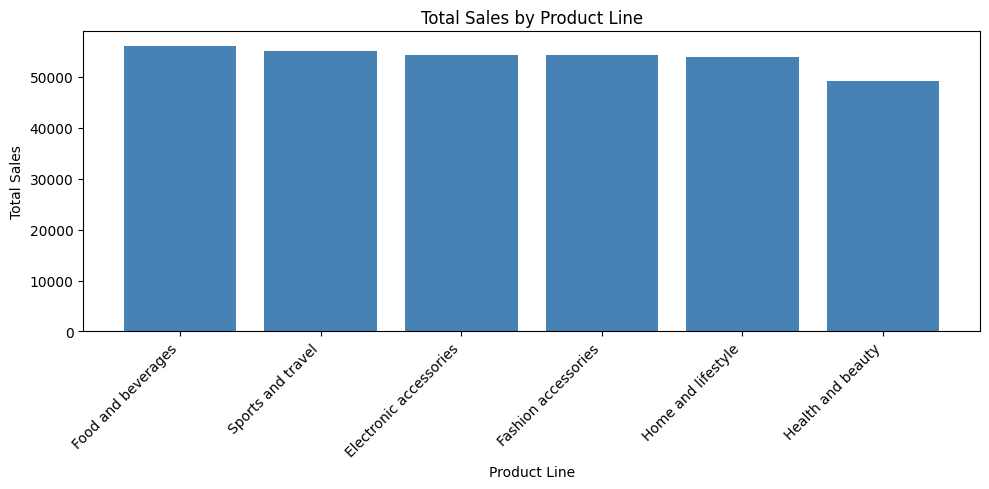

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_summary["product_line"],
    product_summary["total_sales"],
    color="steelblue"
)

plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    charts_folder / "product_line_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 29.Monthly sales chart

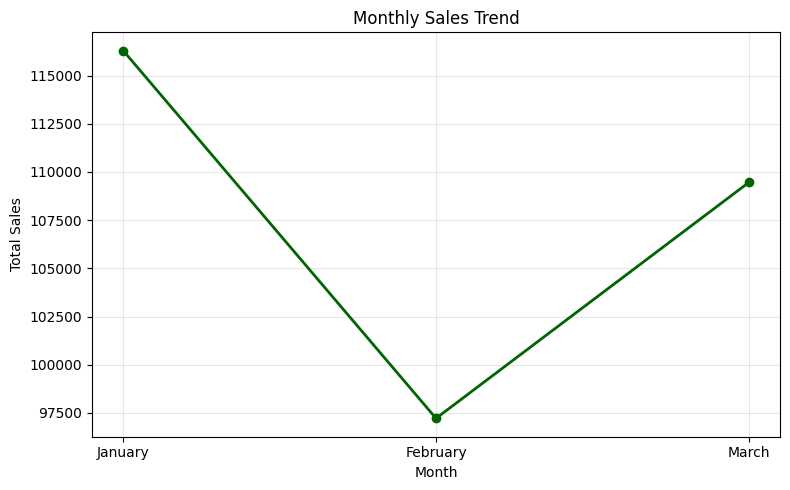

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_sales["month_name"],
    monthly_sales["total_sales"],
    marker="o",
    linewidth=2,
    color="darkgreen"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    charts_folder / "monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 30.Branch sales chart

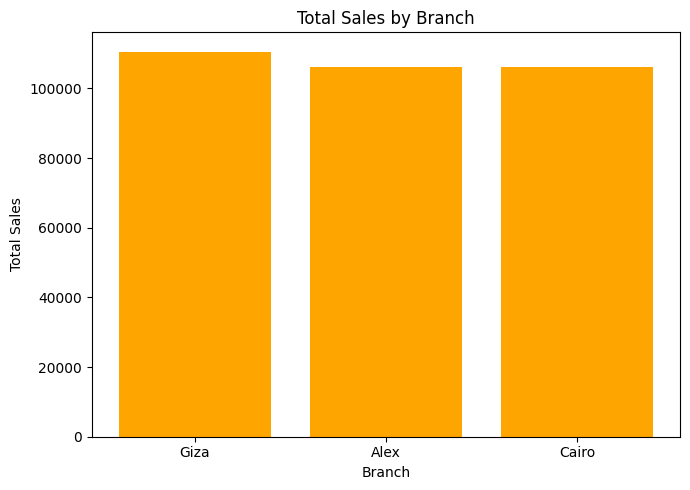

In [30]:
plt.figure(figsize=(7, 5))

plt.bar(
    branch_summary["branch"],
    branch_summary["total_sales"],
    color="orange"
)

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    charts_folder / "branch_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 31.Final quality check

In [31]:
print("FINAL DATA QUALITY REPORT")
print("-------------------------")

print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Invalid quantities:", len(invalid_quantities))
print("Invalid ratings:", len(invalid_ratings))
print(
    "Negative financial rows:",
    len(invalid_financial_values)
)

print("\nData types:")
print(df.dtypes)

FINAL DATA QUALITY REPORT
-------------------------
Shape: (1000, 21)
Missing values: 0
Duplicate rows: 0
Invalid quantities: 0
Invalid ratings: 0
Negative financial rows: 0

Data types:
invoice_id                 string[python]
branch                     string[python]
city                       string[python]
customer_type              string[python]
gender                     string[python]
product_line               string[python]
unit_price                        float64
quantity                            int64
tax_amount                        float64
total_sales                       float64
date                       datetime64[ns]
time                               object
payment                    string[python]
cost_of_goods_sold                float64
gross_margin_percentage           float64
gross_income                      float64
rating                            float64
year                                int32
month                               int32
month_name     

## 32.Save the cleaned dataset

In [32]:
cleaned_data_path = (
    output_folder / "cleaned_supermarket_sales.csv"
)

df.to_csv(
    cleaned_data_path,
    index=False
)

print("Cleaned dataset saved to:")
print(cleaned_data_path)

Cleaned dataset saved to:
/Users/iswarya/Projects/Ishu Tableau/data/kaggle_supermarket_sales/outputs/cleaned_supermarket_sales.csv


## 33.Save all summary tables

In [33]:
product_summary.to_csv(
    output_folder / "product_summary.csv",
    index=False
)

branch_summary.to_csv(
    output_folder / "branch_summary.csv",
    index=False
)

customer_summary.to_csv(
    output_folder / "customer_summary.csv",
    index=False
)

customer_gender_summary.to_csv(
    output_folder / "customer_gender_summary.csv",
    index=False
)

payment_summary.to_csv(
    output_folder / "payment_summary.csv",
    index=False
)

monthly_sales.to_csv(
    output_folder / "monthly_sales.csv",
    index=False
)

daily_sales.to_csv(
    output_folder / "daily_sales.csv",
    index=False
)

best_product_by_branch.to_csv(
    output_folder / "best_product_by_branch.csv",
    index=False
)

print("All summary tables saved successfully")

All summary tables saved successfully


## 34.Verify the exported dataset

In [34]:
check_df = pd.read_csv(cleaned_data_path)

print("Exported shape:", check_df.shape)
print("Exported columns:")
print(check_df.columns.tolist())

check_df.head()

Exported shape: (1000, 21)
Exported columns:
['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_amount', 'total_sales', 'date', 'time', 'payment', 'cost_of_goods_sold', 'gross_margin_percentage', 'gross_income', 'rating', 'year', 'month', 'month_name', 'day_name']


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_amount,total_sales,...,time,payment,cost_of_goods_sold,gross_margin_percentage,gross_income,rating,year,month,month_name,day_name
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,2019,1,January,Saturday
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,10:29:00,Cash,76.40,4.761905,3.8200,9.6,2019,3,March,Friday
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,...,13:23:00,Credit card,324.31,4.761905,16.2155,7.4,2019,3,March,Sunday
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,...,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,2019,1,January,Sunday
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,...,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2019,2,February,Friday
